In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision rasterio tqdm scikit-learn matplotlib

ValueError: mount failed

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling

data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load 10m bands
b04 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B04_10m.jp2').read(1).astype(np.float32)
b08 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B08_10m.jp2').read(1).astype(np.float32)

# Resample 20m bands to 10m
with rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B11_20m.jp2') as src:
    new_shape = (src.height * 2, src.width * 2)
    b11 = src.read(1, out_shape=new_shape, resampling=Resampling.bilinear).astype(np.float32)

with rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B12_20m.jp2') as src:
    b12 = src.read(1, out_shape=new_shape, resampling=Resampling.bilinear).astype(np.float32)

# Save resampled bands so you don't have to do this again
profile = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B04_10m.jp2').profile

with rasterio.open(f'{data_dir}/2025/B11_10m_resampled.tif', 'w', **profile) as dst:
    dst.write(b11, 1)

with rasterio.open(f'{data_dir}/2025/B12_10m_resampled.tif', 'w', **profile) as dst:
    dst.write(b12, 1)

print("Resampled bands saved!")
print(f"B04 shape: {b04.shape}")
print(f"B11 shape: {b11.shape} (should match B04)")

Resampled bands saved!
B04 shape: (10980, 10980)
B11 shape: (10980, 10980) (should match B04)


In [ ]:
import numpy as np
import rasterio
import random
import pickle
from tqdm import tqdm

data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load
b04 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B04_10m.jp2').read(1).astype(np.float32)
b08 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B08_10m.jp2').read(1).astype(np.float32)
b11 = rasterio.open(f'{data_dir}/2025/B11_10m_resampled.tif').read(1).astype(np.float32)
b12 = rasterio.open(f'{data_dir}/2025/B12_10m_resampled.tif').read(1).astype(np.float32)

with rasterio.open(f'{data_dir}/deforestation_binary_10m.tif') as src:
    labels = src.read(1)

image = np.stack([b04, b08, b11, b12], axis=-1)

for i in range(4):
    mi, ma = image[:,:,i].min(), image[:,:,i].max()
    image[:,:,i] = (image[:,:,i] - mi) / (ma - mi)

# Use subset
subset = 2000
image = image[:subset, :subset, :]
labels = labels[:subset, :subset]

patch_size = 128
patches = []

for _ in tqdm(range(300)):
    y = random.randint(0, subset - patch_size)
    x = random.randint(0, subset - patch_size)
    img_patch = image[y:y+patch_size, x:x+patch_size, :]
    lbl_patch = labels[y:y+patch_size, x:x+patch_size]
    patches.append((img_patch.copy(), lbl_patch.copy()))

with open(f'{data_dir}/patches.pkl', 'wb') as f:
    pickle.dump(patches, f)

print(f"Saved {len(patches)} patches")

100%|██████████| 300/300 [00:00<00:00, 11981.10it/s]


Saved 300 patches


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np

data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches")

# Dataset class
class DeforestationDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()
        return img, lbl

# Split train/val
split = int(0.8 * len(patches))
train_dataset = DeforestationDataset(patches[:split])
val_dataset = DeforestationDataset(patches[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train patches: {len(train_dataset)}, Val patches: {len(val_dataset)}")

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()

        # Encoder
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder2 = DoubleConv(features[0], features[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder3 = DoubleConv(features[1], features[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.encoder4 = DoubleConv(features[2], features[3])
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(features[3], features[3] * 2)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(features[3] * 2, features[3], kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(features[3] * 2, features[3])

        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(features[2] * 2, features[2])

        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1] * 2, features[1])

        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0] * 2, features[0])

        # Output
        self.conv_out = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool4(enc4))

        # Decoder with skip connections
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        # Output
        out = self.conv_out(dec1)
        out = self.sigmoid(out)

        return out

# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=4, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

print(f"Training on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training loop
for epoch in range(20):
    model.train()
    train_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        pred = model(imgs)
        loss = criterion(pred, lbls)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            pred = model(imgs)
            val_loss += criterion(pred, lbls).item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save model
torch.save(model.state_dict(), f'{data_dir}/unet_model.pth')
print(f"\nModel saved to {data_dir}/unet_model.pth")

# Quick test
model.eval()
with torch.no_grad():
    test_img, test_lbl = next(iter(val_loader))
    test_img = test_img.to(device)
    test_pred = model(test_img)
    print(f"\n Prediction shape: {test_pred.shape}")
    print(f"   Prediction range: {test_pred.min():.3f} - {test_pred.max():.3f}")

Loaded 300 patches
Train patches: 240, Val patches: 60
Training on cuda
Model parameters: 31,044,097
Epoch  1 | Train Loss: 0.5152 | Val Loss: 0.6980
Epoch  2 | Train Loss: 0.3369 | Val Loss: 0.5140
Epoch  3 | Train Loss: 0.2798 | Val Loss: 0.3057
Epoch  4 | Train Loss: 0.2469 | Val Loss: 0.2433
Epoch  5 | Train Loss: 0.2265 | Val Loss: 0.2273
Epoch  6 | Train Loss: 0.2164 | Val Loss: 0.2204
Epoch  7 | Train Loss: 0.2076 | Val Loss: 0.2568
Epoch  8 | Train Loss: 0.2022 | Val Loss: 0.1998
Epoch  9 | Train Loss: 0.1971 | Val Loss: 0.3337
Epoch 10 | Train Loss: 0.1953 | Val Loss: 0.2091
Epoch 11 | Train Loss: 0.1930 | Val Loss: 0.2331
Epoch 12 | Train Loss: 0.1894 | Val Loss: 0.2120
Epoch 13 | Train Loss: 0.1894 | Val Loss: 0.2294
Epoch 14 | Train Loss: 0.1883 | Val Loss: 0.1853
Epoch 15 | Train Loss: 0.1850 | Val Loss: 0.1884
Epoch 16 | Train Loss: 0.1868 | Val Loss: 0.2174
Epoch 17 | Train Loss: 0.1860 | Val Loss: 0.1848
Epoch 18 | Train Loss: 0.1842 | Val Loss: 0.1990
Epoch 19 | Train 

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Resample 2026 B11 and B12 to 10m
print("Resampling 2026 bands...")

# Get reference shape from B04 (10m)
with rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B04_10m.jp2') as src:
    ref_profile = src.profile
    ref_shape = (src.height, src.width)
    print(f"Reference shape (10m): {ref_shape}")

# Resample B11
with rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B11_20m.jp2') as src:
    b11_resampled = src.read(1, out_shape=ref_shape, resampling=Resampling.bilinear)

    # Save resampled
    out_profile = src.profile.copy()
    out_profile.update({
        'height': ref_shape[0],
        'width': ref_shape[1],
        'transform': ref_profile['transform']
    })

    with rasterio.open(f'{data_dir}/2026/B11_10m_resampled.tif', 'w', **out_profile) as dst:
        dst.write(b11_resampled, 1)
    print("B11 resampled and saved")

# Resample B12
with rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B12_20m.jp2') as src:
    b12_resampled = src.read(1, out_shape=ref_shape, resampling=Resampling.bilinear)

    with rasterio.open(f'{data_dir}/2026/B12_10m_resampled.tif', 'w', **out_profile) as dst:
        dst.write(b12_resampled, 1)
    print("B12 resampled and saved")

print(" 2026 resampling complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resampling 2026 bands...
Reference shape (10m): (10980, 10980)


B11 resampled and saved


B12 resampled and saved
✅ 2026 resampling complete!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
STEP 2: Loading 2026 bands
Image shape: (10980, 10980, 4)

STEP 3: Loading trained model
Model loaded on cuda

STEP 4: Running prediction on subset
Subset shape: (2000, 2000, 4)
Total patches: 900


Predicting: 100%|██████████| 29/29 [00:05<00:00,  5.74it/s]



STEP 5: Saving results
Saved: deforestation_probability_2026.tif
Saved: deforestation_binary_2026.tif

RESULTS
Total pixels in subset: 4000000
Deforested pixels: 122832
Deforested area: 1228.32 hectares
Deforestation percentage: 3.07%

Results saved to: /content/drive/MyDrive/DEFORESTATION/deforestation_results_2026.txt


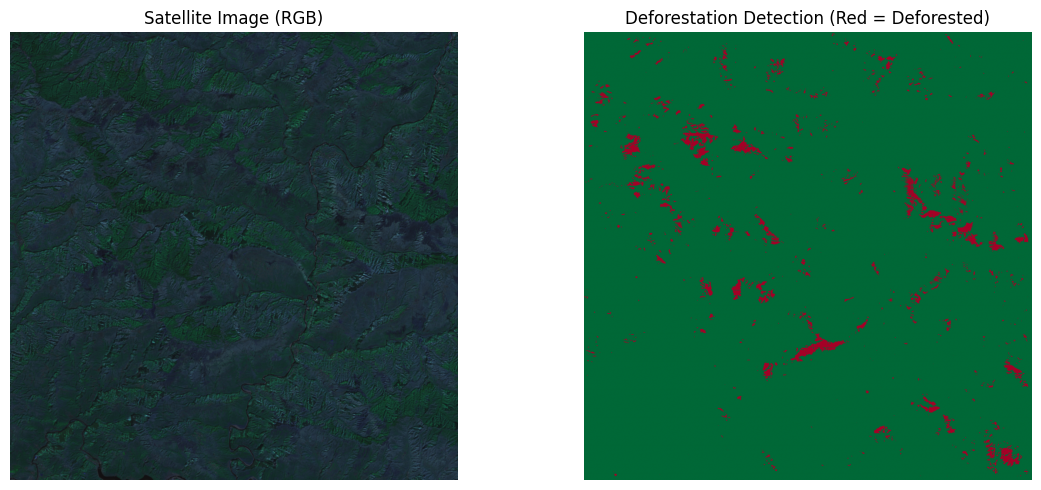


✅ COMPLETE! Files saved:
   - /content/drive/MyDrive/DEFORESTATION/deforestation_probability_2026.tif
   - /content/drive/MyDrive/DEFORESTATION/deforestation_binary_2026.tif
   - /content/drive/MyDrive/DEFORESTATION/deforestation_map_2026.png
   - /content/drive/MyDrive/DEFORESTATION/deforestation_results_2026.txt


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import rasterio
from rasterio.enums import Resampling
from google.colab import drive
from tqdm import tqdm
import matplotlib.pyplot as plt

# Mount drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/DEFORESTATION'

print("STEP 2: Loading 2026 bands")
print("=" * 50)

# Load all bands as float32
b04 = rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B04_10m.jp2').read(1).astype(np.float32)
b08 = rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B08_10m.jp2').read(1).astype(np.float32)
b11 = rasterio.open(f'{data_dir}/2026/B11_10m_resampled.tif').read(1).astype(np.float32)
b12 = rasterio.open(f'{data_dir}/2026/B12_10m_resampled.tif').read(1).astype(np.float32)

# Stack and normalize
image = np.stack([b04, b08, b11, b12], axis=-1)
for i in range(4):
    mi, ma = image[:,:,i].min(), image[:,:,i].max()
    if ma - mi > 0:
        image[:,:,i] = (image[:,:,i] - mi) / (ma - mi)

print(f"Image shape: {image.shape}")

print("\n" + "=" * 50)
print("STEP 3: Loading trained model")
print("=" * 50)

# U-Net architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder2 = DoubleConv(features[0], features[1])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder3 = DoubleConv(features[1], features[2])
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder4 = DoubleConv(features[2], features[3])
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = DoubleConv(features[3], features[3] * 2)
        self.upconv4 = nn.ConvTranspose2d(features[3] * 2, features[3], kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(features[3] * 2, features[3])
        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(features[2] * 2, features[2])
        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1] * 2, features[1])
        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0] * 2, features[0])
        self.conv_out = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))
        bottleneck = self.bottleneck(self.pool4(enc4))
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        out = self.conv_out(dec1)
        return self.sigmoid(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=4, out_channels=1).to(device)
model.load_state_dict(torch.load(f'{data_dir}/unet_model.pth', map_location=device))
model.eval()
print(f"Model loaded on {device}")

print("\n" + "=" * 50)
print("STEP 4: Running prediction on subset")
print("=" * 50)

# Use subset for faster prediction
subset_size = 2000
image_subset = image[:subset_size, :subset_size, :]
print(f"Subset shape: {image_subset.shape}")

# Predict on subset using sliding window
patch_size = 128
stride = 64
h, w = image_subset.shape[:2]

# Calculate output size
output_h = ((h - patch_size) // stride + 1) * stride + patch_size
output_w = ((w - patch_size) // stride + 1) * stride + patch_size
output_h = min(output_h, h)
output_w = min(output_w, w)

result = np.zeros((output_h, output_w), dtype=np.float32)
count = np.zeros((output_h, output_w), dtype=np.float32)

# Collect patches
patches = []
positions = []
for y in range(0, output_h - patch_size + 1, stride):
    for x in range(0, output_w - patch_size + 1, stride):
        patch = image_subset[y:y+patch_size, x:x+patch_size, :]
        patches.append(patch)
        positions.append((y, x))

print(f"Total patches: {len(patches)}")

# Predict in batches
batch_size = 32
with torch.no_grad():
    for i in tqdm(range(0, len(patches), batch_size), desc="Predicting"):
        batch_patches = patches[i:i+batch_size]
        batch_tensors = torch.stack([
            torch.from_numpy(p).permute(2, 0, 1).float() for p in batch_patches
        ]).to(device)

        batch_preds = model(batch_tensors).cpu().numpy()

        for j, (y, x) in enumerate(positions[i:i+batch_size]):
            result[y:y+patch_size, x:x+patch_size] += batch_preds[j, 0]
            count[y:y+patch_size, x:x+patch_size] += 1

# Average overlapping predictions
result = result / (count + 1e-6)

print("\n" + "=" * 50)
print("STEP 5: Saving results")
print("=" * 50)

# Save as GeoTIFF (using proper profile)
with rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B04_10m.jp2') as src:
    transform = src.transform
    crs = src.crs

# Save probability map (float32)
with rasterio.open(f'{data_dir}/deforestation_probability_2026.tif', 'w',
                   driver='GTiff', height=result.shape[0], width=result.shape[1],
                   count=1, dtype='float32', crs=crs, transform=transform,
                   compress='lzw') as dst:
    dst.write(result, 1)
print("Saved: deforestation_probability_2026.tif")

# Save binary map (uint8 for QGIS)
binary = (result > 0.5).astype(np.uint8)
with rasterio.open(f'{data_dir}/deforestation_binary_2026.tif', 'w',
                   driver='GTiff', height=result.shape[0], width=result.shape[1],
                   count=1, dtype='uint8', crs=crs, transform=transform,
                   compress='lzw') as dst:
    dst.write(binary, 1)
print("Saved: deforestation_binary_2026.tif")

# Calculate area
deforested_pixels = np.sum(binary)
pixel_area_ha = 0.01  # 10m x 10m = 0.01 ha
deforested_ha = deforested_pixels * pixel_area_ha

print("\n" + "=" * 50)
print("RESULTS")
print("=" * 50)
print(f"Total pixels in subset: {binary.size}")
print(f"Deforested pixels: {deforested_pixels}")
print(f"Deforested area: {deforested_ha:.2f} hectares")
print(f"Deforestation percentage: {(deforested_pixels / binary.size) * 100:.2f}%")

# Save results to text file
with open(f'{data_dir}/deforestation_results_2026.txt', 'w') as f:
    f.write("DEFORESTATION DETECTION RESULTS (Deep Learning)\n")
    f.write("=" * 50 + "\n")
    f.write(f"Total pixels: {binary.size}\n")
    f.write(f"Deforested pixels: {deforested_pixels}\n")
    f.write(f"Deforested area: {deforested_ha:.2f} hectares\n")
    f.write(f"Deforestation percentage: {(deforested_pixels / binary.size) * 100:.2f}%\n")

print(f"\nResults saved to: {data_dir}/deforestation_results_2026.txt")

# Visualize result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RGB visualization (using B04, B08, B11)
rgb = np.stack([
    image_subset[:result.shape[0], :result.shape[1], 0],
    image_subset[:result.shape[0], :result.shape[1], 1],
    image_subset[:result.shape[0], :result.shape[1], 2]
], axis=-1)
rgb = np.clip(rgb, 0, 1)

axes[0].imshow(rgb)
axes[0].set_title("Satellite Image (RGB)")
axes[0].axis('off')

axes[1].imshow(binary, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title("Deforestation Detection (Red = Deforested)")
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/deforestation_map_2026.png', dpi=150)
plt.show()

print("\nCOMPLETE! Files saved:")
print(f"   - {data_dir}/deforestation_probability_2026.tif")
print(f"   - {data_dir}/deforestation_binary_2026.tif")
print(f"   - {data_dir}/deforestation_map_2026.png")
print(f"   - {data_dir}/deforestation_results_2026.txt")

LOADING DATA
Prediction shape: (2000, 2000)
Ground truth shape: (10980, 10980)
Resampling ground truth to match prediction...
Resampled shape: (2000, 2000)

CONFUSION MATRIX

                  Predicted
                  Forest  Deforest
Actual   Forest    3641321     117822
         Deforest   235847       5010

METRICS

Overall Accuracy:      91.16%
Precision:             4.08%
Recall (Sensitivity):  2.08%
Specificity:           96.87%
F1 Score:              2.76%
Kappa Coefficient:     -0.0137
IoU (Jaccard Index):   1.40%

User's Accuracy:       4.08%
Producer's Accuracy:   2.08%

CLASSIFICATION REPORT
               precision    recall  f1-score   support

       Forest       0.94      0.97      0.95   3759143
Deforestation       0.04      0.02      0.03    240857

     accuracy                           0.91   4000000
    macro avg       0.49      0.49      0.49   4000000
 weighted avg       0.89      0.91      0.90   4000000


AREA ESTIMATION

                           Actual   

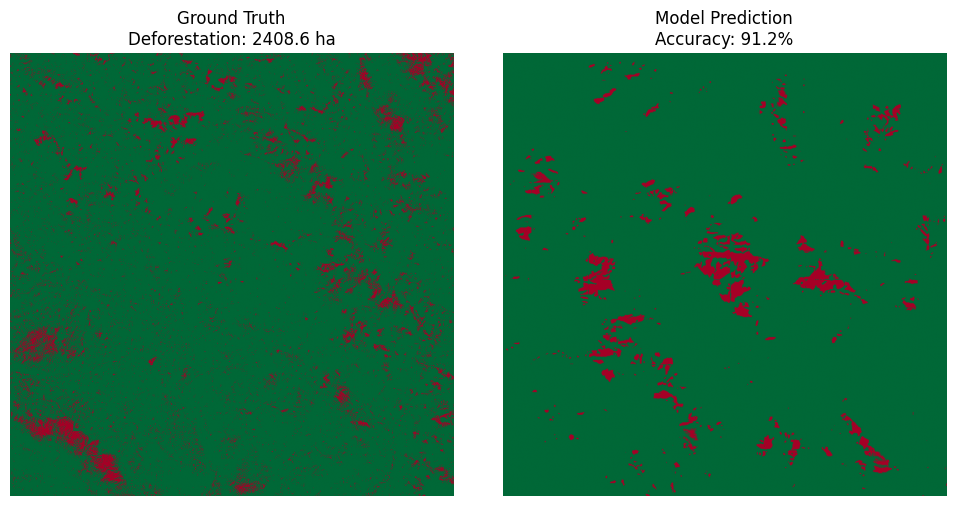

✅ Comparison image saved to: /content/drive/MyDrive/DEFORESTATION/accuracy_comparison.png


In [ ]:
import numpy as np
import rasterio
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/DEFORESTATION'

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load your prediction (binary map)
with rasterio.open(f'{data_dir}/deforestation_binary_2026.tif') as src:
    prediction = src.read(1)
print(f"Prediction shape: {prediction.shape}")

# Load ground truth (your threshold 0.1 map)
with rasterio.open(f'{data_dir}/deforestation_binary_10m.tif') as src:
    ground_truth = src.read(1)
print(f"Ground truth shape: {ground_truth.shape}")

# Resample ground truth to match prediction size if needed
if ground_truth.shape != prediction.shape:
    print("Resampling ground truth to match prediction...")
    from scipy.ndimage import zoom
    zoom_h = prediction.shape[0] / ground_truth.shape[0]
    zoom_w = prediction.shape[1] / ground_truth.shape[1]
    ground_truth = zoom(ground_truth, (zoom_h, zoom_w), order=0)
    ground_truth = (ground_truth > 0.5).astype(np.uint8)
    print(f"Resampled shape: {ground_truth.shape}")

# Flatten arrays
y_true = ground_truth.flatten()
y_pred = prediction.flatten()

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"\n                  Predicted")
print(f"                  Forest  Deforest")
print(f"Actual   Forest   {tn:8d}   {fp:8d}")
print(f"         Deforest {fn:8d}   {tp:8d}")

print("\n" + "=" * 60)
print("METRICS")
print("=" * 60)

# Calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
kappa = cohen_kappa_score(y_true, y_pred)

# User's and Producer's accuracy
users_accuracy = tp / (tp + fp) if (tp + fp) > 0 else 0
producers_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0

# IoU (Jaccard)
iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0

# Specificity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nOverall Accuracy:      {accuracy*100:.2f}%")
print(f"Precision:             {precision*100:.2f}%")
print(f"Recall (Sensitivity):  {recall*100:.2f}%")
print(f"Specificity:           {specificity*100:.2f}%")
print(f"F1 Score:              {f1_score*100:.2f}%")
print(f"Kappa Coefficient:     {kappa:.4f}")
print(f"IoU (Jaccard Index):   {iou*100:.2f}%")
print(f"\nUser's Accuracy:       {users_accuracy*100:.2f}%")
print(f"Producer's Accuracy:   {producers_accuracy*100:.2f}%")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=['Forest', 'Deforestation']))

print("\n" + "=" * 60)
print("AREA ESTIMATION")
print("=" * 60)

pixel_area_ha = 0.01  # 10m x 10m

actual_forest_pixels = np.sum(y_true == 0)
actual_deforest_pixels = np.sum(y_true == 1)
predicted_forest_pixels = np.sum(y_pred == 0)
predicted_deforest_pixels = np.sum(y_pred == 1)

actual_forest_ha = actual_forest_pixels * pixel_area_ha
actual_deforest_ha = actual_deforest_pixels * pixel_area_ha
predicted_forest_ha = predicted_forest_pixels * pixel_area_ha
predicted_deforest_ha = predicted_deforest_pixels * pixel_area_ha

print(f"\n{'':20} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
print("-" * 60)
print(f"{'Forest (ha)':20} {actual_forest_ha:12.2f} {predicted_forest_ha:12.2f} {actual_forest_ha - predicted_forest_ha:12.2f}")
print(f"{'Deforestation (ha)':20} {actual_deforest_ha:12.2f} {predicted_deforest_ha:12.2f} {actual_deforest_ha - predicted_deforest_ha:12.2f}")

# Error percentages
if actual_deforest_ha > 0:
    deforest_error_pct = abs(actual_deforest_ha - predicted_deforest_ha) / actual_deforest_ha * 100
    print(f"\nDeforestation area error: {deforest_error_pct:.2f}%")

print("\n" + "=" * 60)
print("QUALITY ASSESSMENT")
print("=" * 60)

# Overestimation/underestimation
if predicted_deforest_pixels > actual_deforest_pixels:
    over_estimation = predicted_deforest_pixels - actual_deforest_pixels
    print(f"Model OVER-estimates deforestation by {over_estimation} pixels ({over_estimation * pixel_area_ha:.2f} ha)")
else:
    under_estimation = actual_deforest_pixels - predicted_deforest_pixels
    print(f"Model UNDER-estimates deforestation by {under_estimation} pixels ({under_estimation * pixel_area_ha:.2f} ha)")

# Save metrics to file
with open(f'{data_dir}/accuracy_metrics.txt', 'w') as f:
    f.write("DEFORESTATION MODEL ACCURACY METRICS\n")
    f.write("=" * 60 + "\n\n")
    f.write("CONFUSION MATRIX\n")
    f.write(f"Actual Forest / Predicted Forest: {tn}\n")
    f.write(f"Actual Forest / Predicted Deforest: {fp}\n")
    f.write(f"Actual Deforest / Predicted Forest: {fn}\n")
    f.write(f"Actual Deforest / Predicted Deforest: {tp}\n\n")
    f.write(f"Overall Accuracy: {accuracy*100:.2f}%\n")
    f.write(f"Precision: {precision*100:.2f}%\n")
    f.write(f"Recall: {recall*100:.2f}%\n")
    f.write(f"Specificity: {specificity*100:.2f}%\n")
    f.write(f"F1 Score: {f1_score*100:.2f}%\n")
    f.write(f"Kappa: {kappa:.4f}\n")
    f.write(f"IoU: {iou*100:.2f}%\n")
    f.write(f"User's Accuracy: {users_accuracy*100:.2f}%\n")
    f.write(f"Producer's Accuracy: {producers_accuracy*100:.2f}%\n\n")
    f.write("AREA ESTIMATION\n")
    f.write(f"Actual Forest Area: {actual_forest_ha:.2f} ha\n")
    f.write(f"Predicted Forest Area: {predicted_forest_ha:.2f} ha\n")
    f.write(f"Actual Deforestation Area: {actual_deforest_ha:.2f} ha\n")
    f.write(f"Predicted Deforestation Area: {predicted_deforest_ha:.2f} ha\n")

print(f"\nMetrics saved to: {data_dir}/accuracy_metrics.txt")

# Simple visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Ground truth
axes[0].imshow(ground_truth[:1000, :1000], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title(f'Ground Truth\nDeforestation: {actual_deforest_ha:.1f} ha')
axes[0].axis('off')

# Prediction
axes[1].imshow(prediction[:1000, :1000], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title(f'Model Prediction\nAccuracy: {accuracy*100:.1f}%')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/accuracy_comparison.png', dpi=150)
plt.show()

print(f"Comparison image saved to: {data_dir}/accuracy_comparison.png")

QUICK FIX: TESTING DIFFERENT THRESHOLDS
Probability range: 0.000 - 0.968
Mean probability: 0.098

THRESHOLD ANALYSIS
Threshold  Deforest Pixels    Deforest Area(ha)  Recall     Precision 
----------------------------------------------------------------------
0.05       1494899            14948.99           33.22     % 5.35      %
0.10       968407             9684.07            20.59     % 5.12      %
0.15       781080             7810.80            16.20     % 4.99      %
0.20       660058             6600.58            13.37     % 4.88      %
0.25       560744             5607.44            11.07     % 4.75      %
0.30       472197             4721.97            9.11      % 4.64      %
0.35       385927             3859.27            7.23      % 4.51      %
0.40       299983             2999.83            5.44      % 4.37      %
0.45       210416             2104.16            3.69      % 4.23      %
0.50       122832             1228.32            2.08      % 4.08      %

✅ BEST THR

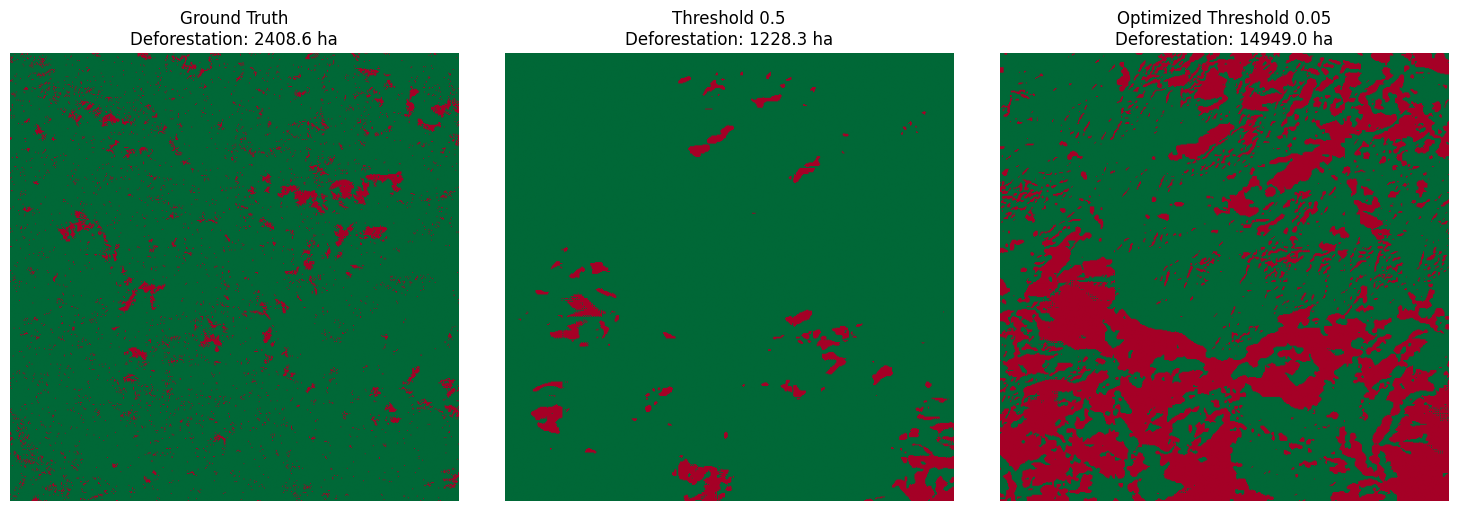

✅ Comparison saved: /content/drive/MyDrive/DEFORESTATION/threshold_comparison.png


In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/DEFORESTATION'

print("=" * 60)
print("QUICK FIX: TESTING DIFFERENT THRESHOLDS")
print("=" * 60)

# Load your probability map
with rasterio.open(f'{data_dir}/deforestation_probability_2026.tif') as src:
    prob = src.read(1)

# Load ground truth
with rasterio.open(f'{data_dir}/deforestation_binary_10m.tif') as src:
    truth_raw = src.read(1)

# Resample truth to match
from scipy.ndimage import zoom
zoom_factor = prob.shape[0] / truth_raw.shape[0]
truth = zoom(truth_raw, (zoom_factor, zoom_factor), order=0)
truth = (truth > 0.5).astype(np.uint8)

print(f"Probability range: {prob.min():.3f} - {prob.max():.3f}")
print(f"Mean probability: {prob.mean():.3f}")

# Test different thresholds
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

print("\n" + "=" * 60)
print("THRESHOLD ANALYSIS")
print("=" * 60)
print(f"{'Threshold':<10} {'Deforest Pixels':<18} {'Deforest Area(ha)':<18} {'Recall':<10} {'Precision':<10}")
print("-" * 70)

results = []

for thresh in thresholds:
    binary = (prob > thresh).astype(np.uint8)

    # Calculate metrics
    pred_pixels = np.sum(binary)
    pred_area = pred_pixels * 0.01

    # Confusion matrix
    tp = np.sum((binary == 1) & (truth == 1))
    fp = np.sum((binary == 1) & (truth == 0))
    fn = np.sum((binary == 0) & (truth == 1))

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'threshold': thresh,
        'pixels': pred_pixels,
        'area': pred_area,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn
    })

    print(f"{thresh:<10.2f} {pred_pixels:<18} {pred_area:<18.2f} {recall*100:<10.2f}% {precision*100:<10.2f}%")

print("=" * 60)

# Find best threshold by F1 score
best = max(results, key=lambda x: x['f1'])
print(f"\nBEST THRESHOLD: {best['threshold']}")
print(f"   F1 Score: {best['f1']*100:.2f}%")
print(f"   Recall: {best['recall']*100:.2f}%")
print(f"   Precision: {best['precision']*100:.2f}%")
print(f"   Deforestation Area: {best['area']:.2f} ha")

# Save best threshold map
best_binary = (prob > best['threshold']).astype(np.uint8)

with rasterio.open(f'/content/drive/MyDrive/DEFORESTATION/2026/T44RKU_20260212T052941_B04_10m.jp2') as src:
    transform = src.transform
    crs = src.crs

with rasterio.open(f'{data_dir}/deforestation_binary_optimized.tif', 'w',
                   driver='GTiff', height=best_binary.shape[0], width=best_binary.shape[1],
                   count=1, dtype='uint8', crs=crs, transform=transform,
                   compress='lzw') as dst:
    dst.write(best_binary, 1)

print(f"\nSaved optimized binary map: {data_dir}/deforestation_binary_optimized.tif")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ground truth
axes[0].imshow(truth[:500, :500], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title(f'Ground Truth\nDeforestation: {np.sum(truth)*0.01:.1f} ha')
axes[0].axis('off')

# Original threshold 0.5
original = (prob > 0.5).astype(np.uint8)
axes[1].imshow(original[:500, :500], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title(f'Threshold 0.5\nDeforestation: {np.sum(original)*0.01:.1f} ha')
axes[1].axis('off')

# Optimized threshold
axes[2].imshow(best_binary[:500, :500], cmap='RdYlGn_r', vmin=0, vmax=1)
axes[2].set_title(f'Optimized Threshold {best["threshold"]}\nDeforestation: {best["area"]:.1f} ha')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/threshold_comparison.png', dpi=150)
plt.show()

print(f"Comparison saved: {data_dir}/threshold_comparison.png")

In [ ]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import random
import pickle
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

print("=" * 60)
print("LOADING DATA (SUBSET)")
print("=" * 60)

subset_size = 3000

# Load bands
b04 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B04_10m.jp2').read(1).astype(np.float32)
b08 = rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B08_10m.jp2').read(1).astype(np.float32)

with rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B11_20m.jp2') as src:
    ref_shape = (b04.shape[0], b04.shape[1])
    b11 = src.read(1, out_shape=ref_shape, resampling=Resampling.bilinear).astype(np.float32)

with rasterio.open(f'{data_dir}/2025/T44RKU_20250212T052839_B12_20m.jp2') as src:
    b12 = src.read(1, out_shape=ref_shape, resampling=Resampling.bilinear).astype(np.float32)

# Subset
b04 = b04[:subset_size, :subset_size]
b08 = b08[:subset_size, :subset_size]
b11 = b11[:subset_size, :subset_size]
b12 = b12[:subset_size, :subset_size]

image = np.stack([b04, b08, b11, b12], axis=-1)

for i in range(4):
    mi, ma = image[:,:,i].min(), image[:,:,i].max()
    if ma - mi > 0:
        image[:,:,i] = (image[:,:,i] - mi) / (ma - mi)

# Labels
with rasterio.open(f'{data_dir}/deforestation_binary_10m.tif') as src:
    labels_raw = src.read(1)

from scipy.ndimage import zoom
zoom_h = subset_size / labels_raw.shape[0]
zoom_w = subset_size / labels_raw.shape[1]
labels = zoom(labels_raw, (zoom_h, zoom_w), order=0)
labels = (labels > 0).astype(np.float32)

print(f"Labels shape: {labels.shape}")
print(f"Deforestation: {np.sum(labels == 1)}")
print(f"Forest: {np.sum(labels == 0)}")

print("\n" + "=" * 60)
print("EXTRACTING EXACTLY BALANCED PATCHES")
print("=" * 60)

patch_size = 128
num_patches = 400  # Total patches
num_deforest = num_patches // 2  # 200
num_forest = num_patches // 2     # 200

patches = []

# Get coordinates
deforest_coords = list(zip(*np.where(labels == 1)))
forest_coords = list(zip(*np.where(labels == 0)))

print(f"Available deforestation coords: {len(deforest_coords)}")
print(f"Available forest coords: {len(forest_coords)}")

# Extract deforestation patches (PURE deforestation - >50% deforest)
print("\nExtracting PURE deforestation patches...")
deforest_extracted = 0

while deforest_extracted < num_deforest and len(deforest_coords) > 0:
    idx = random.randint(0, len(deforest_coords) - 1)
    y, x = deforest_coords[idx]

    y_start = max(0, y - patch_size // 2)
    x_start = max(0, x - patch_size // 2)

    if y_start + patch_size > labels.shape[0]:
        y_start = labels.shape[0] - patch_size
    if x_start + patch_size > labels.shape[1]:
        x_start = labels.shape[1] - patch_size

    if y_start < 0 or x_start < 0:
        continue

    img_patch = image[y_start:y_start+patch_size, x_start:x_start+patch_size, :].copy()
    lbl_patch = labels[y_start:y_start+patch_size, x_start:x_start+patch_size].copy()

    # Check if patch has >30% deforestation (not just a few pixels)
    deforest_ratio = np.sum(lbl_patch == 1) / (patch_size * patch_size)

    if deforest_ratio > 0.3:  # At least 30% deforestation
        patches.append((img_patch, lbl_patch))
        deforest_extracted += 1

        if deforest_extracted % 50 == 0:
            print(f"  {deforest_extracted}/{num_deforest}")

print(f"Extracted {deforest_extracted} deforestation patches")

# Extract forest patches (PURE forest - >95% forest)
print("\nExtracting PURE forest patches...")
forest_extracted = 0

while forest_extracted < num_forest and len(forest_coords) > 0:
    idx = random.randint(0, len(forest_coords) - 1)
    y, x = forest_coords[idx]

    y_start = max(0, y - patch_size // 2)
    x_start = max(0, x - patch_size // 2)

    if y_start + patch_size > labels.shape[0]:
        y_start = labels.shape[0] - patch_size
    if x_start + patch_size > labels.shape[1]:
        x_start = labels.shape[1] - patch_size

    if y_start < 0 or x_start < 0:
        continue

    img_patch = image[y_start:y_start+patch_size, x_start:x_start+patch_size, :].copy()
    lbl_patch = labels[y_start:y_start+patch_size, x_start:x_start+patch_size].copy()

    # Check if patch has >95% forest (less than 5% deforestation)
    deforest_ratio = np.sum(lbl_patch == 1) / (patch_size * patch_size)

    if deforest_ratio < 0.05:  # Less than 5% deforestation
        patches.append((img_patch, lbl_patch))
        forest_extracted += 1

        if forest_extracted % 50 == 0:
            print(f"  {forest_extracted}/{num_forest}")

print(f"Extracted {forest_extracted} forest patches")

# Shuffle
random.shuffle(patches)

# Save
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'wb') as f:
    pickle.dump(patches, f)

print(f"\nTotal patches: {len(patches)}")
print(f"   Deforestation patches: {deforest_extracted}")
print(f"   Forest patches: {forest_extracted}")

# Verify one sample
img, lbl = patches[0]
print(f"\nSample patch shape: {img.shape}")
print(f"Sample label range: {lbl.min()} - {lbl.max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LOADING DATA (SUBSET)
Labels shape: (3000, 3000)
Deforestation: 543682
Forest: 8456318

EXTRACTING EXACTLY BALANCED PATCHES
Available deforestation coords: 543682
Available forest coords: 8456318

Extracting PURE deforestation patches...
  50/200
  100/200
  150/200
  200/200
Extracted 200 deforestation patches

Extracting PURE forest patches...
  50/200
  100/200
  150/200
  200/200
Extracted 200 forest patches

✅ Total patches: 400
   Deforestation patches: 200
   Forest patches: 200

Sample patch shape: (128, 128, 4)
Sample label range: 0.0 - 1.0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 400 patches
Train: 320, Val: 80
Training on cuda
--------------------------------------------------
Epoch  1 | Train Loss: 0.7006 | Val Loss: 0.6911
Epoch  2 | Train Loss: 0.6819 | Val Loss: 0.6911
Epoch  3 | Train Loss: 0.6824 | Val Loss: 0.6911
Epoch  4 | Train Loss: 0.6817 | Val Loss: 0.6911
Epoch  5 | Train Loss: 0.6819 | Val Loss: 0.6911
Epoch  6 | Train Loss: 0.6819 | Val Loss: 0.6911
Epoch  7 | Train Loss: 0.6820 | Val Loss: 0.6911
Epoch  8 | Train Loss: 0.6831 | Val Loss: 0.6911
Epoch  9 | Train Loss: 0.6823 | Val Loss: 0.6911
Epoch 10 | Train Loss: 0.6834 | Val Loss: 0.6911
Epoch 11 | Train Loss: 0.6809 | Val Loss: 0.6911
Epoch 12 | Train Loss: 0.6816 | Val Loss: 0.6911
Epoch 13 | Train Loss: 0.6812 | Val Loss: 0.6911
Epoch 14 | Train Loss: 0.6814 | Val Loss: 0.6911
Epoch 15 | Train Loss: 0.6814 | Val Loss: 0.6911
Epoch 16 | Train Loss: 0.6818

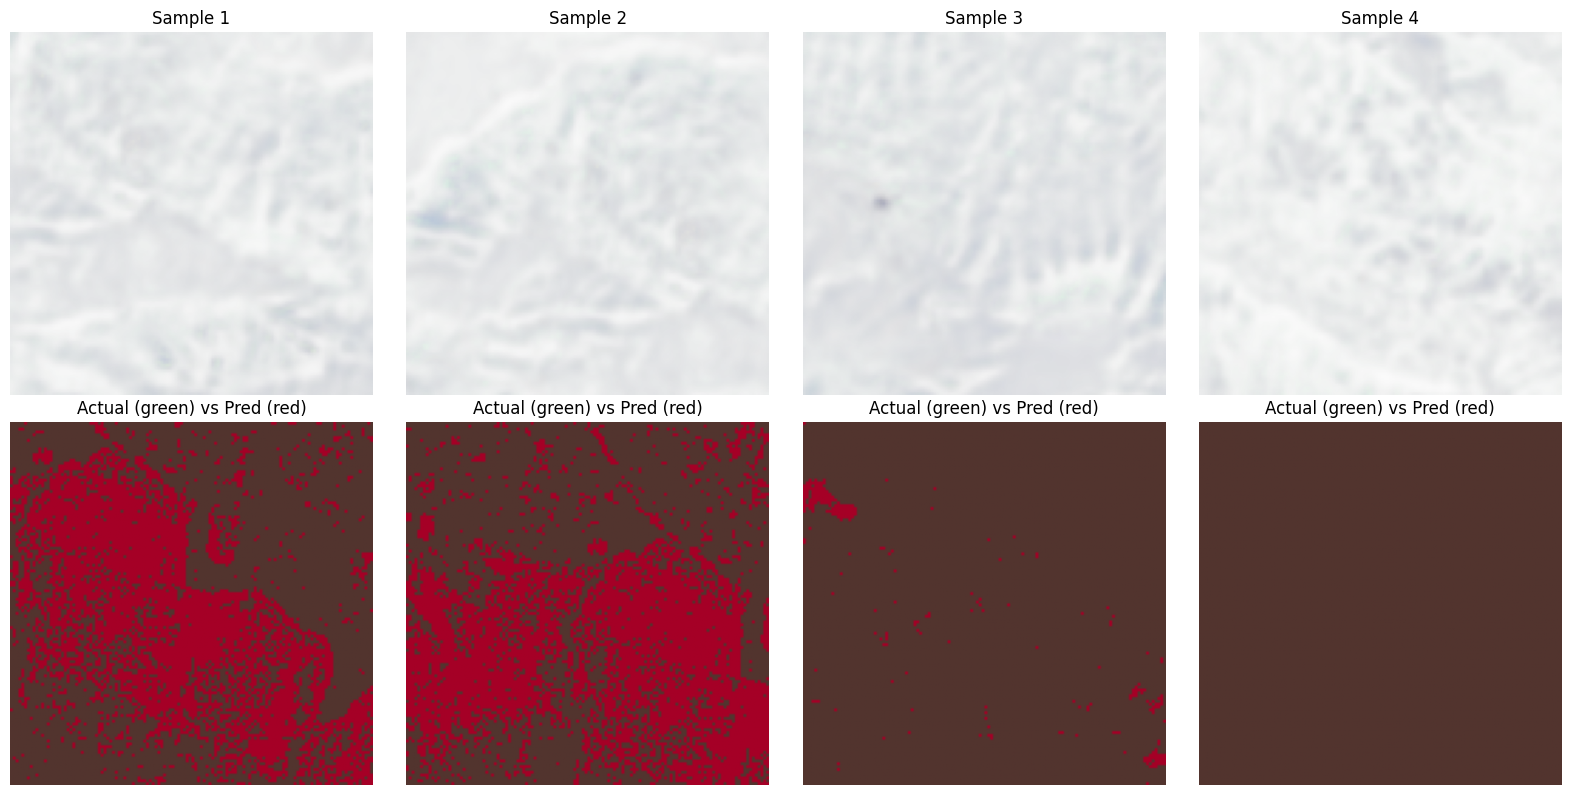


✅ Done! Files saved to /content/drive/MyDrive/DEFORESTATION/


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches")

# Dataset - resize everything to consistent size
class PatchDataset(Dataset):
    def __init__(self, patches, size=128):
        self.patches = patches
        self.size = size

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        # Convert to tensor and resize
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()

        # Resize to consistent size
        img = F.interpolate(img.unsqueeze(0), size=(self.size, self.size), mode='bilinear').squeeze(0)
        lbl = F.interpolate(lbl.unsqueeze(0), size=(self.size, self.size), mode='nearest').squeeze(0)

        return img, lbl

# Split
split = int(0.8 * len(patches))
train_dataset = PatchDataset(patches[:split])
val_dataset = PatchDataset(patches[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

class SimpleSegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(4, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.enc4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1), nn.ReLU())

        # Decoder
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(512, 256, 2, stride=2), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU())

        # Output
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # Encoder
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        x = self.dec4(x)
        x = self.dec3(x)
        x = self.dec2(x)
        x = self.dec1(x)

        # Output
        x = self.out(x)
        return torch.sigmoid(x)

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        smooth = 1e-6
        pred = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return 1 - dice

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleSegmentationModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = DiceLoss()

print(f"Training on {device}")
print("-" * 50)

# Training
for epoch in range(30):
    model.train()
    train_loss = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, lbl)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            pred = model(img)
            val_loss += criterion(pred, lbl).item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save
torch.save(model.state_dict(), f'{data_dir}/model_simple.pth')
print(f"\nModel saved")

# Evaluation
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for img, lbl in val_loader:
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)
        pred_binary = (pred > 0.5).cpu().numpy().flatten()
        lbl_binary = lbl.cpu().numpy().flatten()
        all_preds.extend(pred_binary)
        all_true.extend(lbl_binary)

# Metrics
tn, fp, fn, tp = confusion_matrix(all_true, all_preds, labels=[0, 1]).ravel()
acc = (tp+tn)/(tp+tn+fp+fn)
prec = tp/(tp+fp) if tp+fp>0 else 0
rec = tp/(tp+fn) if tp+fn>0 else 0
f1 = 2*prec*rec/(prec+rec) if prec+rec>0 else 0
kappa = cohen_kappa_score(all_true, all_preds)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"Confusion Matrix:")
print(f"            Predicted")
print(f"            Forest  Deforest")
print(f"Actual Forest  {tn:5d}   {fp:5d}")
print(f"       Deforest {fn:5d}   {tp:5d}")
print(f"\nAccuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"Kappa:     {kappa:.4f}")

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

with torch.no_grad():
    for i in range(min(4, len(val_dataset))):
        img, lbl = val_dataset[i]
        img_tensor = img.unsqueeze(0).to(device)
        pred = model(img_tensor).squeeze().cpu().numpy()

        # RGB
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = np.clip(img_disp, 0, 1)
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        # Overlay
        axes[1, i].imshow(lbl.squeeze().numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1, i].imshow(pred, cmap='RdYlGn_r', alpha=0.5, vmin=0, vmax=1)
        axes[1, i].set_title(f'Actual (green) vs Pred (red)')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/comparison.png', dpi=150)
plt.show()

print(f"\nDone! Files saved to {data_dir}/")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches")

# Dataset
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()
        # Resize labels to match model output (will be 128x128)
        lbl = F.interpolate(lbl.unsqueeze(0), size=(128, 128), mode='nearest').squeeze(0)
        return img, lbl

# Split
split = int(0.8 * len(patches))
train_dataset = PatchDataset(patches[:split])
val_dataset = PatchDataset(patches[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(4, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)           # 64
        e2 = self.enc2(self.pool(e1))  # 128
        e3 = self.enc3(self.pool(e2))  # 256
        e4 = self.enc4(self.pool(e3))  # 512

        # Decoder with skip
        d4 = self.up4(e4)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.out(d1))

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        smooth = 1e-6
        pred = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return 1 - dice

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = DiceLoss()

print(f"Training on {device}")
print("-" * 50)

# Training
for epoch in range(25):
    model.train()
    train_loss = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, lbl)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            pred = model(img)
            val_loss += criterion(pred, lbl).item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save model
torch.save(model.state_dict(), f'{data_dir}/unet_final.pth')
print(f"\nModel saved")

# Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for img, lbl in val_loader:
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)
        pred_binary = (pred > 0.5).cpu().numpy().flatten()
        lbl_binary = lbl.cpu().numpy().flatten()
        all_preds.extend(pred_binary)
        all_targets.extend(lbl_binary)

# Metrics
tn, fp, fn, tp = confusion_matrix(all_targets, all_preds, labels=[0, 1]).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
kappa = cohen_kappa_score(all_targets, all_preds)

print("\n" + "="*50)
print("FINAL METRICS")
print("="*50)
print(f"Confusion Matrix:")
print(f"            Predicted")
print(f"            Forest  Deforest")
print(f"Actual Forest  {tn:5d}   {fp:5d}")
print(f"       Deforest {fn:5d}   {tp:5d}")
print(f"\nAccuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"Kappa:     {kappa:.4f}")

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

with torch.no_grad():
    for i in range(min(4, len(val_dataset))):
        img, lbl = val_dataset[i]
        img_tensor = img.unsqueeze(0).to(device)
        pred = model(img_tensor).squeeze().cpu().numpy()

        # RGB
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = np.clip(img_disp, 0, 1)
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        # Overlay
        axes[1, i].imshow(lbl.squeeze().numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1, i].imshow(pred, cmap='RdYlGn_r', alpha=0.5, vmin=0, vmax=1)
        axes[1, i].set_title(f'Actual (green) vs Pred (red)')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/comparison.png', dpi=150)
plt.show()

print(f"\nSaved: {data_dir}/comparison.png")
print(f"Saved: {data_dir}/unet_final.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 400 patches
Train: 320, Val: 80
Training on cuda
--------------------------------------------------


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 256 but got size 128 for tensor number 1 in the list.

In [ ]:
import pickle
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print("=" * 50)
print("PATCHES ANALYSIS")
print("=" * 50)
print(f"Total patches: {len(patches)}")

# Count forest vs deforestation
forest_patches = 0
deforest_patches = 0
mixed_patches = 0

for i, (img, lbl) in enumerate(patches):
    total_pixels = lbl.shape[0] * lbl.shape[1]
    deforest_pixels = (lbl == 1).sum()
    deforest_ratio = deforest_pixels / total_pixels

    if deforest_ratio < 0.05:
        forest_patches += 1
    elif deforest_ratio > 0.3:
        deforest_patches += 1
    else:
        mixed_patches += 1

print(f"\nForest patches (<5% deforest):     {forest_patches}")
print(f"Deforestation patches (>30% deforest): {deforest_patches}")
print(f"Mixed patches (5-30% deforest):   {mixed_patches}")

# Show sample patches
print("\n" + "=" * 50)
print("SAMPLE PATCHES")
print("=" * 50)

for i in range(min(5, len(patches))):
    img, lbl = patches[i]
    total = lbl.shape[0] * lbl.shape[1]
    deforest = (lbl == 1).sum()
    forest = (lbl == 0).sum()
    ratio = deforest / total * 100

    print(f"Patch {i+1}: {deforest:6d} deforest pixels, {forest:6d} forest pixels ({ratio:.1f}% deforest)")

# Check if balanced enough for training
print("\n" + "=" * 50)
print("READY FOR TRAINING?")
print("=" * 50)

if forest_patches > 50 and deforest_patches > 50:
    print("YES! Good balance. Proceed with training.")
elif forest_patches > 30 and deforest_patches > 30:
    print("MAYBE. Minimum balance. Consider adding more patches.")
else:
    print("NO. Need more balanced patches. Run patch extraction again.")
    print(f"   Need at least 50 forest and 50 deforest patches")
    print(f"   Currently: {forest_patches} forest, {deforest_patches} deforest")

PATCHES ANALYSIS
Total patches: 400

Forest patches (<5% deforest):     200
Deforestation patches (>30% deforest): 200
Mixed patches (5-30% deforest):   0

SAMPLE PATCHES
Patch 1:    596 deforest pixels,  15788 forest pixels (3.6% deforest)
Patch 2:   7050 deforest pixels,   9334 forest pixels (43.0% deforest)
Patch 3:   5075 deforest pixels,  11309 forest pixels (31.0% deforest)
Patch 4:    412 deforest pixels,  15972 forest pixels (2.5% deforest)
Patch 5:   5346 deforest pixels,  11038 forest pixels (32.6% deforest)

READY FOR TRAINING?
✅ YES! Good balance. Proceed with training.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches (200 forest, 200 deforest)")

# Dataset
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        return torch.from_numpy(img).permute(2,0,1).float(), torch.from_numpy(lbl).unsqueeze(0).float()

# Split
split = int(0.8 * len(patches))
train_dataset = PatchDataset(patches[:split])
val_dataset = PatchDataset(patches[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# Simple U-Net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(4, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.Conv2d(512, 512, 3, padding=1), nn.ReLU())

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = nn.Sequential(nn.Conv2d(512, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Decoder with skip connections
        d4 = self.up4(e4)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.out(d1))

# Dice Loss for imbalanced data
class DiceLoss(nn.Module):
    def forward(self, pred, target):
        smooth = 1e-6
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        return 1 - dice

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = DiceLoss()

print(f"\nTraining on {device}")
print("-" * 50)

# Training
for epoch in range(25):
    model.train()
    train_loss = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, lbl)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            pred = model(img)
            val_loss += criterion(pred, lbl).item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save model
torch.save(model.state_dict(), f'{data_dir}/unet_final.pth')
print(f"\nModel saved to {data_dir}/unet_final.pth")

# Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for img, lbl in val_loader:
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)
        pred_binary = (pred > 0.5).cpu().numpy().flatten()
        all_preds.extend(pred_binary)
        all_targets.extend(lbl.cpu().numpy().flatten())

# Metrics
tn, fp, fn, tp = confusion_matrix(all_targets, all_preds, labels=[0, 1]).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"Confusion Matrix:")
print(f"            Predicted")
print(f"            Forest  Deforest")
print(f"Actual Forest  {tn:5d}   {fp:5d}")
print(f"       Deforest {fn:5d}   {tp:5d}")
print(f"\nAccuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

# Quick visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

with torch.no_grad():
    for i in range(min(4, len(val_dataset))):
        img, lbl = val_dataset[i]
        img_tensor = img.unsqueeze(0).to(device)
        pred = model(img_tensor).squeeze().cpu().numpy()

        axes[0, i].imshow(img.permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(lbl.squeeze().numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1, i].imshow(pred, cmap='RdYlGn_r', alpha=0.5, vmin=0, vmax=1)
        axes[1, i].set_title(f'Actual (green) vs Pred (red)')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/comparison.png', dpi=150)
plt.show()

print(f"\nComparison saved: {data_dir}/comparison.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 400 patches (200 forest, 200 deforest)
Train: 320, Val: 80

Training on cpu
--------------------------------------------------


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 256 but got size 128 for tensor number 1 in the list.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches")

# Dataset - returns whole patches as is
class SimpleDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        # Resize to 224x224 for pretrained model
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()

        # Resize image to 224x224
        img = nn.functional.interpolate(img.unsqueeze(0), size=(224, 224), mode='bilinear').squeeze(0)
        # Resize label to 224x224
        lbl = nn.functional.interpolate(lbl.unsqueeze(0), size=(224, 224), mode='nearest').squeeze(0)

        return img, lbl

# Split
split = int(0.8 * len(patches))
train_dataset = SimpleDataset(patches[:split])
val_dataset = SimpleDataset(patches[split:])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# Use pretrained ResNet as encoder
import torchvision.models as models

class PretrainedUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pretrained ResNet
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Encoder (using ResNet layers)
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool1 = resnet.maxpool
        self.enc2 = resnet.layer1
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3

        # Decoder
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(80, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
        )

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e1_pool = self.pool1(e1)
        e2 = self.enc2(e1_pool)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Decoder with skip
        d4 = self.up4(e4)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        # Handle size mismatch for e1
        d2 = self.up2(d3)
        if d2.shape[-2:] != e1.shape[-2:]:
            e1 = nn.functional.interpolate(e1, size=d2.shape[-2:], mode='bilinear')
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            e1 = nn.functional.interpolate(e1, size=d1.shape[-2:], mode='bilinear')
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out(d1)
        out = nn.functional.interpolate(out, size=(224, 224), mode='bilinear')
        return torch.sigmoid(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PretrainedUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

print(f"Training on {device}")
print("-" * 50)

# Training
for epoch in range(20):
    model.train()
    train_loss = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, lbl)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            pred = model(img)
            val_loss += criterion(pred, lbl).item()

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save
torch.save(model.state_dict(), f'{data_dir}/pretrained_model.pth')
print(f"\nModel saved")

# Evaluation
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for img, lbl in val_loader:
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)
        pred_binary = (pred > 0.5).cpu().numpy().flatten()
        all_preds.extend(pred_binary)
        all_true.extend(lbl.cpu().numpy().flatten())

tn, fp, fn, tp = confusion_matrix(all_true, all_preds, labels=[0, 1]).ravel()
acc = (tp+tn)/(tp+tn+fp+fn)
prec = tp/(tp+fp) if tp+fp>0 else 0
rec = tp/(tp+fn) if tp+fn>0 else 0
f1 = 2*prec*rec/(prec+rec) if prec+rec>0 else 0

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"Confusion Matrix:")
print(f"            Predicted")
print(f"            Forest  Deforest")
print(f"Actual Forest  {tn:5d}   {fp:5d}")
print(f"       Deforest {fn:5d}   {tp:5d}")
print(f"\nAccuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

with torch.no_grad():
    for i in range(min(4, len(val_dataset))):
        img, lbl = val_dataset[i]
        img_tensor = img.unsqueeze(0).to(device)
        pred = model(img_tensor).squeeze().cpu().numpy()

        axes[0, i].imshow(img.permute(1, 2, 0).numpy())
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(lbl.squeeze().numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1, i].imshow(pred, cmap='RdYlGn_r', alpha=0.5, vmin=0, vmax=1)
        axes[1, i].set_title(f'Actual (green) vs Pred (red)')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/comparison_pretrained.png', dpi=150)
plt.show()

print(f"\nDone!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 400 patches
Train: 320, Val: 80
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


Training on cpu
--------------------------------------------------


RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[16, 4, 224, 224] to have 3 channels, but got 4 channels instead

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 400 patches
Train: 320, Val: 80
Training on cpu
--------------------------------------------------
Epoch  1 | Train Loss: 1.2498 | Val Loss: 1.3025 | LR: 0.001000
Epoch  2 | Train Loss: 1.1929 | Val Loss: 1.3724 | LR: 0.001000
Epoch  3 | Train Loss: 1.1439 | Val Loss: 1.3372 | LR: 0.001000
Epoch  4 | Train Loss: 1.1345 | Val Loss: 1.3122 | LR: 0.001000
Epoch  5 | Train Loss: 1.1250 | Val Loss: 1.3119 | LR: 0.001000
Epoch  6 | Train Loss: 1.0845 | Val Loss: 1.2849 | LR: 0.001000
Epoch  7 | Train Loss: 1.0713 | Val Loss: 1.3200 | LR: 0.001000
Epoch  8 | Train Loss: 1.0603 | Val Loss: 1.1409 | LR: 0.001000
Epoch  9 | Train Loss: 1.0327 | Val Loss: 1.6267 | LR: 0.001000
Epoch 10 | Train Loss: 1.0178 | Val Loss: 1.3463 | LR: 0.001000
Epoch 11 | Train Loss: 1.0144 | Val Loss: 1.5497 | LR: 0.001000
Epoch 12 | Train Loss: 1.0031 | Val Loss: 1.1554 | LR: 0.0010

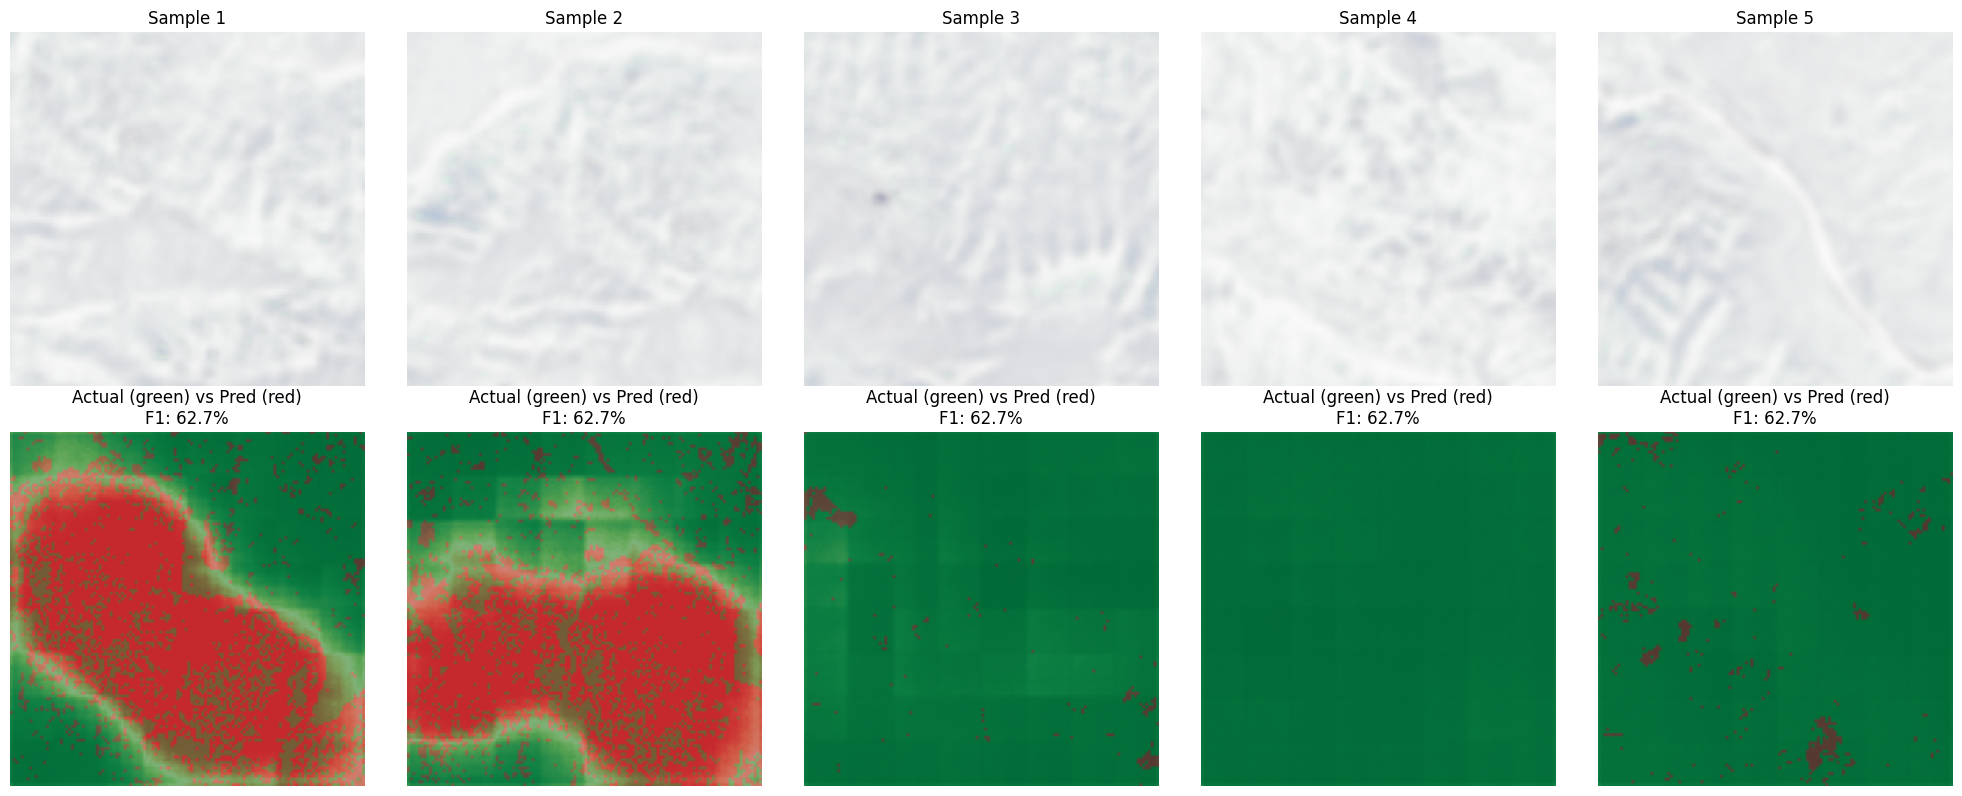


✅ Done! Files saved to /content/drive/MyDrive/DEFORESTATION/
   - model_best.pth (best weights)
   - comparison_improved.png (visualization)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/DEFORESTATION'

# Load patches
with open(f'{data_dir}/patches_balanced_fixed.pkl', 'rb') as f:
    patches = pickle.load(f)

print(f"Loaded {len(patches)} patches")

# Improved Dataset with augmentation
class PatchDataset(Dataset):
    def __init__(self, patches, size=128, augment=False):
        self.patches = patches
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, lbl = self.patches[idx]
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()

        # Resize
        img = F.interpolate(img.unsqueeze(0), size=(self.size, self.size), mode='bilinear').squeeze(0)
        lbl = F.interpolate(lbl.unsqueeze(0), size=(self.size, self.size), mode='nearest').squeeze(0)

        # Data augmentation for training
        if self.augment:
            # Random horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
                lbl = torch.flip(lbl, dims=[2])

            # Random vertical flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])
                lbl = torch.flip(lbl, dims=[1])

            # Random rotation (90, 180, 270)
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, dims=[1, 2])
            lbl = torch.rot90(lbl, k, dims=[1, 2])

        return img, lbl

# Split
split = int(0.8 * len(patches))
train_dataset = PatchDataset(patches[:split], augment=True)
val_dataset = PatchDataset(patches[split:], augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

# IMPROVED MODEL - With BatchNorm and Dropout
class ImprovedSegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (with BatchNorm)
        self.enc1 = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Bottleneck with Dropout
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU()
        )

        # Decoder
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), nn.BatchNorm2d(256), nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.BatchNorm2d(32), nn.ReLU()
        )

        # Output
        self.out = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, 1)
        )

    def forward(self, x):
        # Encoder
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        x = self.dec4(x)
        x = self.dec3(x)
        x = self.dec2(x)
        x = self.dec1(x)

        # Output
        x = self.out(x)

        # Ensure output size matches input size (128x128)
        x = F.interpolate(x, size=(128, 128), mode='bilinear', align_corners=True)

        return torch.sigmoid(x)

# Combined Loss: Dice + BCE
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        # BCE Loss
        bce = self.bce(pred, target)

        # Dice Loss
        smooth = 1e-6
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        dice_loss = 1 - dice

        # Combined (BCE + Dice)
        return bce + dice_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedSegmentationModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = CombinedLoss()

print(f"Training on {device}")
print("-" * 50)

# Training with learning rate scheduling
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(40):  # More epochs
    model.train()
    train_loss = 0
    for img, lbl in train_loader:
        img, lbl = img.to(device), lbl.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, lbl)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            pred = model(img)
            val_loss += criterion(pred, lbl).item()

    val_loss_avg = val_loss / len(val_loader)
    train_loss_avg = train_loss / len(train_loader)

    # Learning rate scheduling
    scheduler.step(val_loss_avg)

    # Save best model
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        torch.save(model.state_dict(), f'{data_dir}/model_best.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter > 10:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss_avg:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# Load best model
model.load_state_dict(torch.load(f'{data_dir}/model_best.pth'))
print(f"\nBest model loaded")

# Evaluation
model.eval()
all_preds, all_true = [], []
all_probs = []

with torch.no_grad():
    for img, lbl in val_loader:
        img, lbl = img.to(device), lbl.to(device)
        pred = model(img)
        pred_binary = (pred > 0.5).cpu().numpy().flatten()
        lbl_binary = lbl.cpu().numpy().flatten()
        all_preds.extend(pred_binary)
        all_true.extend(lbl_binary)
        all_probs.extend(pred.cpu().numpy().flatten())

# Metrics
tn, fp, fn, tp = confusion_matrix(all_true, all_preds, labels=[0, 1]).ravel()
acc = (tp+tn)/(tp+tn+fp+fn)
prec = tp/(tp+fp) if tp+fp>0 else 0
rec = tp/(tp+fn) if tp+fn>0 else 0
f1 = 2*prec*rec/(prec+rec) if prec+rec>0 else 0
kappa = cohen_kappa_score(all_true, all_preds)
iou = tp/(tp+fp+fn) if (tp+fp+fn)>0 else 0

print("\n" + "="*60)
print("IMPROVED RESULTS")
print("="*60)
print(f"Confusion Matrix:")
print(f"            Predicted")
print(f"            Forest  Deforest")
print(f"Actual Forest  {tn:6d}   {fp:6d}")
print(f"       Deforest {fn:6d}   {tp:6d}")
print(f"\nAccuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"Kappa:     {kappa:.4f}")
print(f"IoU:       {iou*100:.2f}%")

# Find best threshold
thresholds = np.arange(0.3, 0.7, 0.05)
best_f1 = 0
best_thresh = 0.5

for thresh in thresholds:
    pred_thresh = np.array(all_probs) > thresh
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(all_true, pred_thresh, labels=[0, 1]).ravel()
    prec_t = tp_t/(tp_t+fp_t) if tp_t+fp_t>0 else 0
    rec_t = tp_t/(tp_t+fn_t) if tp_t+fn_t>0 else 0
    f1_t = 2*prec_t*rec_t/(prec_t+rec_t) if prec_t+rec_t>0 else 0
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = thresh

print(f"\nOptimal threshold: {best_thresh:.2f} (F1: {best_f1*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

with torch.no_grad():
    for i in range(min(5, len(val_dataset))):
        img, lbl = val_dataset[i]
        img_tensor = img.unsqueeze(0).to(device)
        pred = model(img_tensor).squeeze().cpu().numpy()

        # RGB
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = np.clip(img_disp, 0, 1)
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'Sample {i+1}')
        axes[0, i].axis('off')

        # Overlay
        axes[1, i].imshow(lbl.squeeze().numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1, i].imshow(pred, cmap='RdYlGn_r', alpha=0.5, vmin=0, vmax=1)
        axes[1, i].set_title(f'Actual (green) vs Pred (red)\nF1: {f1*100:.1f}%')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{data_dir}/comparison_improved.png', dpi=150)
plt.show()

print(f"\nDone! Files saved to {data_dir}/")
print(f"   - model_best.pth (best weights)")
print(f"   - comparison_improved.png (visualization)")
